Project : Stroke Prediction
Task : The first thing we have to do is labelling the string value into number and then change the column data types into integer, so the machine learning model can understand the data with integer data types. Then we have to do the Exploratory Data Analysis, we can visualize how many people are at risk having stroke and not. The last step is build the machine learning model and visualize the machine learning model, Decision Tree. 


In [1]:
##Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn import tree
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
##Load the Dataset

df = pd.read_csv(r'C:\Users\Shreya\OneDrive\Desktop\Projects\healthcare-stroke\healthcare-dataset-stroke-data.csv')

In [3]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [4]:
##Check Dataset Information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [5]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [6]:
##Fill Missing Values

df['bmi'] = df['bmi'].fillna(df['bmi'].mean())

In [7]:
df.isnull().sum()

id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64

In [8]:
##Convert String Labels into Numbers

le = LabelEncoder()

In [9]:
df['gender'] = le.fit_transform(df['gender'])

df['ever_married'] = le.fit_transform(df['ever_married'])

df['work_type'] = le.fit_transform(df['work_type'])

df['Residence_type'] = le.fit_transform(df['Residence_type'])

df['smoking_status'] = le.fit_transform(df['smoking_status'])

In [10]:
##Convert Data Types into Integer

df = df.astype(int)

In [11]:
df.dtypes

id                   int64
gender               int64
age                  int64
hypertension         int64
heart_disease        int64
ever_married         int64
work_type            int64
Residence_type       int64
avg_glucose_level    int64
bmi                  int64
smoking_status       int64
stroke               int64
dtype: object

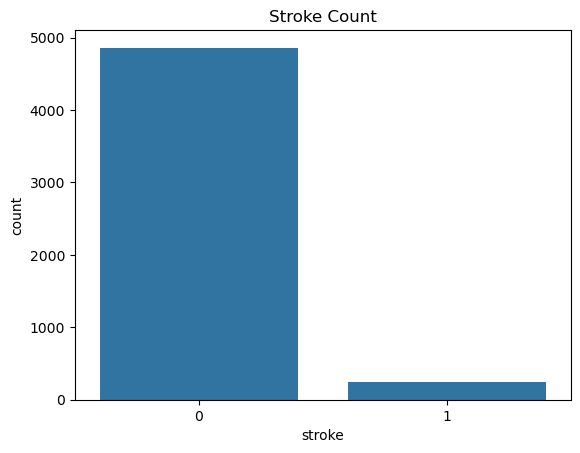

In [12]:
##Exploratory Data Analysis (EDA)

sns.countplot(x='stroke', data=df)
plt.title("Stroke Count")
plt.show()

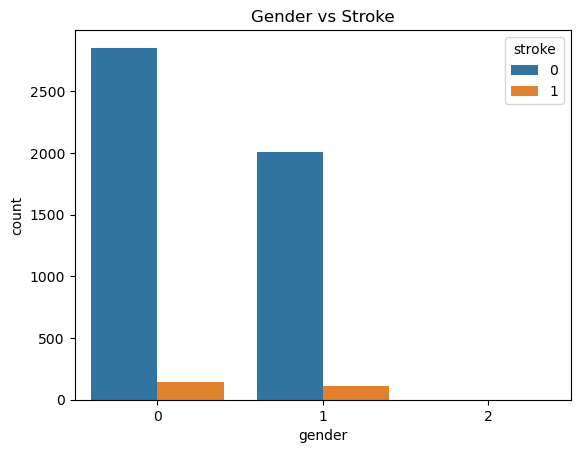

In [13]:
##Gender vs Stroke

sns.countplot(x='gender', hue='stroke', data=df)
plt.title("Gender vs Stroke")
plt.show()

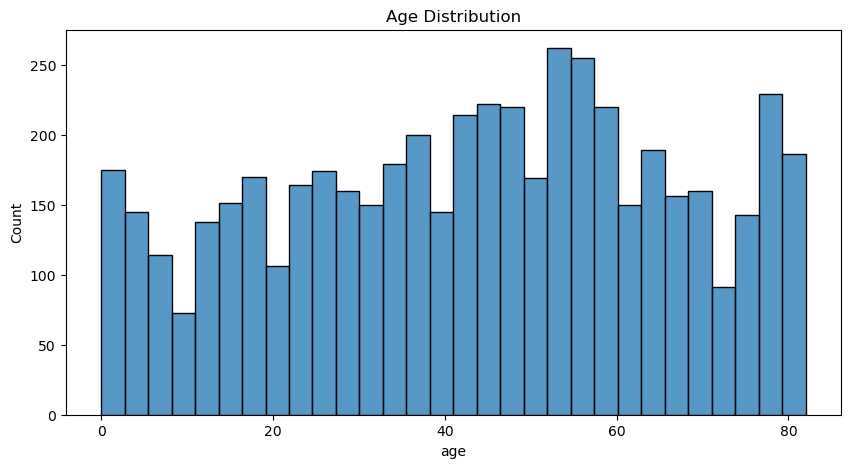

In [14]:
##Age Distribution

plt.figure(figsize=(10,5))
sns.histplot(df['age'], bins=30)
plt.title("Age Distribution")
plt.show()

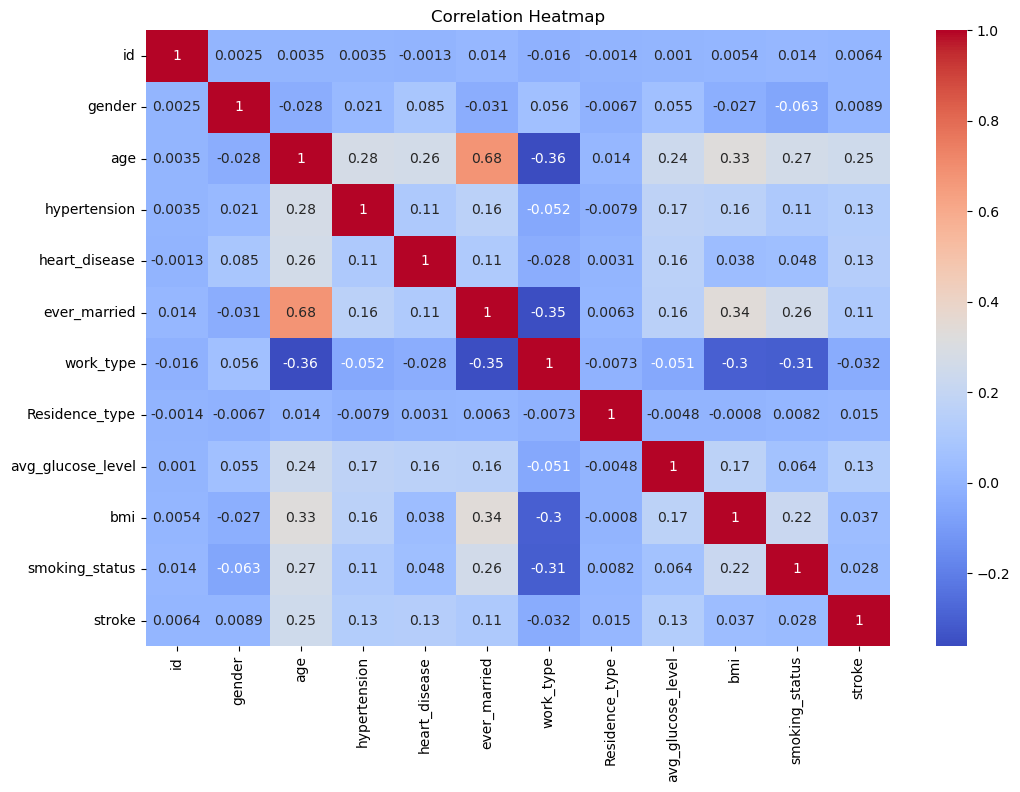

In [15]:
##Correlation Heatmap

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [16]:
##Define Features and Target

X = df.drop('stroke', axis=1)

In [17]:
y = df['stroke']

In [18]:
##Split Dataset into Training and Testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
##Build Decision Tree Model

model = DecisionTreeClassifier(
    random_state=42,
    class_weight='balanced'
)

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [20]:
##Predict the Result

y_pred = model.predict(X_test)

In [21]:
print(y_pred)

[0 0 0 ... 0 0 0]


In [22]:
##Check Accuracy

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9148727984344422


In [23]:
## Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)


[[930  30]
 [ 57   5]]


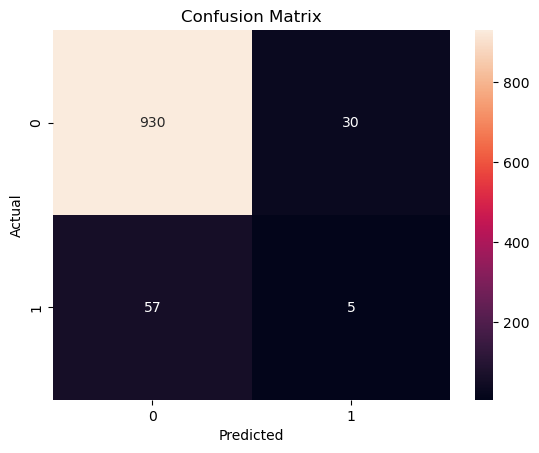

In [24]:
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [25]:
##Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.97      0.96       960
           1       0.14      0.08      0.10        62

    accuracy                           0.91      1022
   macro avg       0.54      0.52      0.53      1022
weighted avg       0.89      0.91      0.90      1022



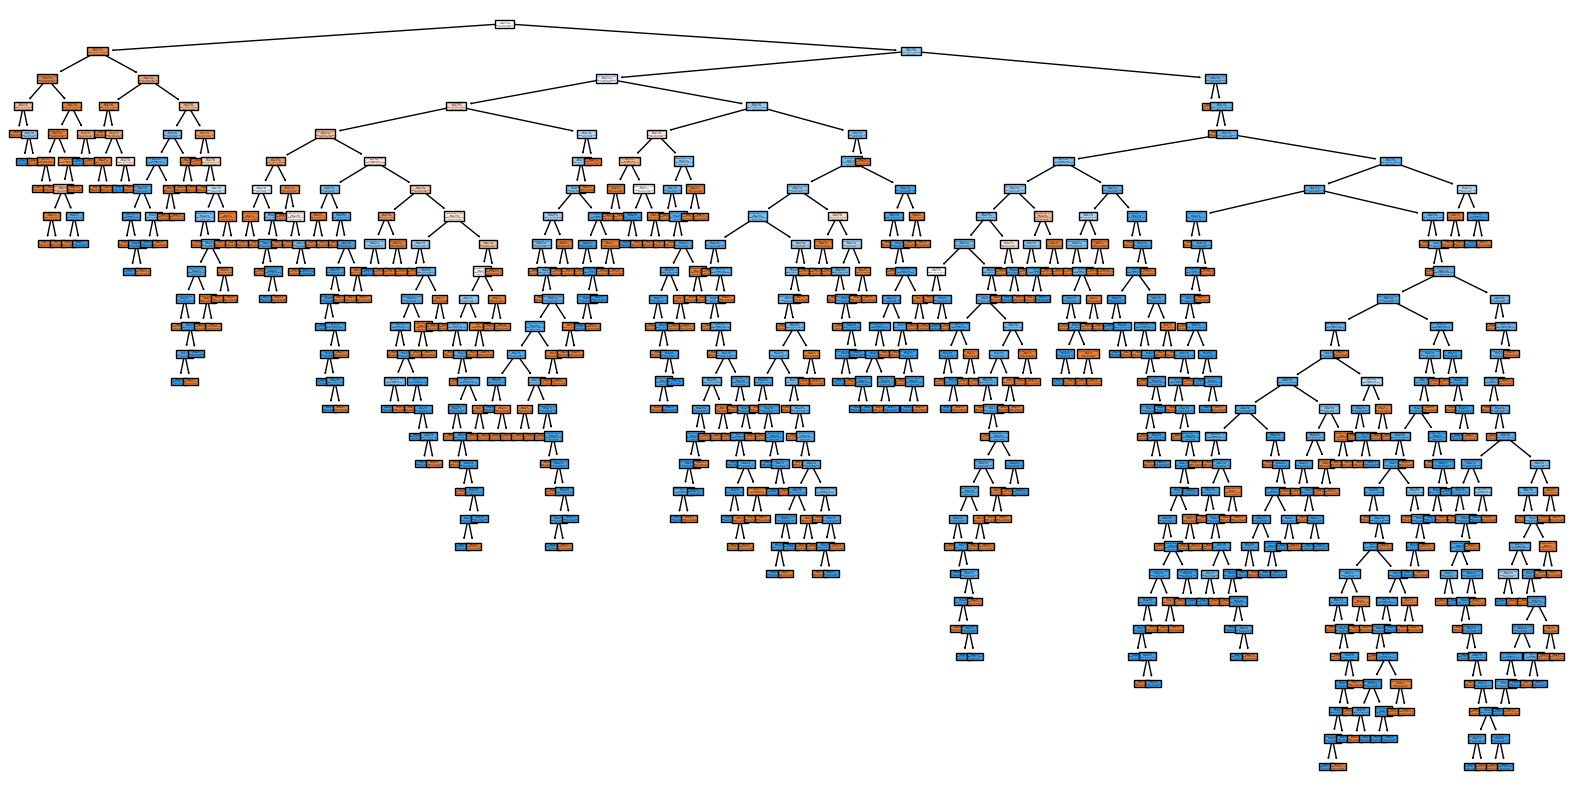

In [26]:
##Visualize Decision Tree

plt.figure(figsize=(20,10))

tree.plot_tree(
    model,
    filled=True,
    feature_names=X.columns,
    class_names=['No Stroke', 'Stroke']
)

plt.show()